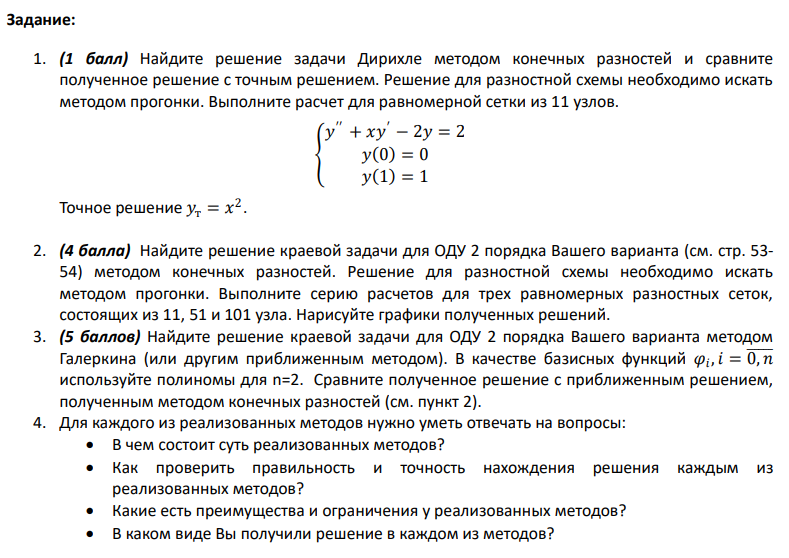  
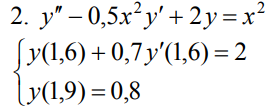

In [44]:
import numpy as np
import matplotlib.pyplot as plt


def p(x):
    return -0.5 * x ** 2


def q(x):
    return 2


def f(x):
    return x**2


a = 1.6
b = 1.9
alpha = 0.7 
mu1 = 2
mu2 = 0.8



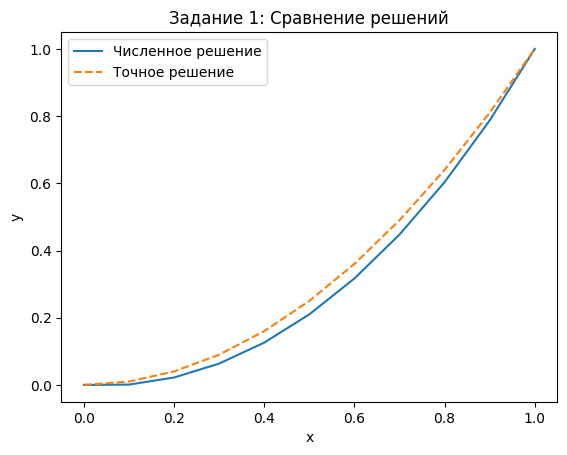

Задание 1: Решение задачи Дирихле
Численное решение: 
 [-7.49400542e-16  9.41228031e-04  2.19876884e-02  6.34487594e-02
  1.25845786e-01  2.09924384e-01  3.16671665e-01  4.47338964e-01
  6.03470881e-01  7.86941627e-01  1.00000000e+00]
Точное решение:  [0.   0.01 0.04 0.09 0.16 0.25 0.36 0.49 0.64 0.81 1.  ]
Максимальная ошибка:  0.04332833532784758
Средняя ошибка:  0.024857183447785505


In [45]:
import numpy as np
import matplotlib.pyplot as plt

def solve_dirichlet():
    # Количество узлов
    n = 11
    h = 1 / (n - 1)
    x = np.linspace(0, 1, n)

    # Матрица для системы линейных уравнений
    A = np.zeros((n, n))
    b = np.full(n, 2)

    # Заполнение матрицы A и вектора b по методу конечных разностей
    for i in range(1, n-1):
        A[i, i-1] = 1 / h**2
        A[i, i] = -2 / h**2 + x[i] / (2 * h)
        A[i, i+1] = 1 / h**2 - x[i] / (2 * h)

    # Граничные условия
    A[0, 0] = 1
    A[n-1, n-1] = 1
    b[0] = 0
    b[n-1] = 1

    y = np.linalg.solve(A, b)
    
    y_exact = x**2

    plt.plot(x, y, label='Численное решение')
    plt.plot(x, y_exact, label='Точное решение', linestyle='--')
    plt.legend()
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Задание 1: Сравнение решений')
    plt.show()

    error = np.abs(y - y_exact)
    print(f"Задание 1: Решение задачи Дирихле")
    print("Численное решение: \n", y)
    print("Точное решение: ", y_exact)
    print("Максимальная ошибка: ", np.max(error))
    print("Средняя ошибка: ", np.mean(error))
    
solve_dirichlet()


при n=11
y = [-0.19088507 -0.09389507  0.00354448  0.10144085  0.19980077  0.29863041
  0.3979354   0.49772074  0.59799086  0.69874956  0.8       ]
при n=51
y = [-0.03328838 -0.01742819 -0.00153662  0.01438643  0.03034107  0.04632742
  0.06234557  0.07839564  0.09447774  0.11059196  0.12673841  0.14291718
  0.15912838  0.17537211  0.19164846  0.20795753  0.2242994   0.24067417
  0.25708194  0.27352278  0.28999678  0.30650404  0.32304463  0.33961863
  0.35622613  0.3728672   0.38954193  0.40625037  0.42299262  0.43976874
  0.4565788   0.47342287  0.49030101  0.5072133   0.52415979  0.54114054
  0.55815562  0.57520509  0.59228899  0.60940738  0.62656032  0.64374786
  0.66097004  0.67822692  0.69551853  0.71284492  0.73020614  0.74760222
  0.7650332   0.78249911  0.8       ]
при n=101
y = [-0.01637949 -0.00864163 -0.00089556  0.00685871  0.01462122  0.02239196
  0.03017096  0.03795824  0.0457538   0.05355766  0.06136983  0.06919034
  0.07701918  0.08485638  0.09270195  0.10055591  0.10841

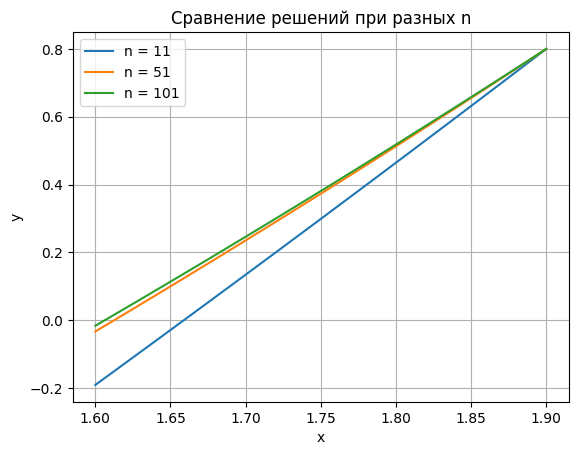

In [46]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

def finite_difference(n):
    x1, x2 = 1.6, 1.9
    y1 = 0.8
    y2 = 2

    h = (x2 - x1) / (n - 1)
    x = np.linspace(x1, x2, n)

    A = np.zeros((n, n))
    b = np.zeros(n)

    for i in range(1, n-1):
        A[i, i-1] = 1 / h**2
        A[i, i] = -2 / h**2 - 0.5 * x[i]**2 / (2 * h)
        A[i, i+1] = 1 / h**2 + 0.5 * x[i]**2 / (2 * h)
        b[i] = x[i]**2

    # граничные условия
    A[0, 0] = 1
    A[0, 1] = -0.7 / h
    b[0] = y2

    A[n-1, n-1] = 1
    b[n-1] = y1

    y = np.linalg.solve(A, b)
    return x, y


# перебор по n
n_values = [11, 51, 101]

plt.figure()

for n in n_values:
    x, y = solve_boundary_value_problem(n)
    print(f"при n={n}")
    print(f"y = {y}")
    plt.plot(x, y, label=f'n = {n}')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение решений при разных n')
plt.legend()
plt.grid()

plt.show()




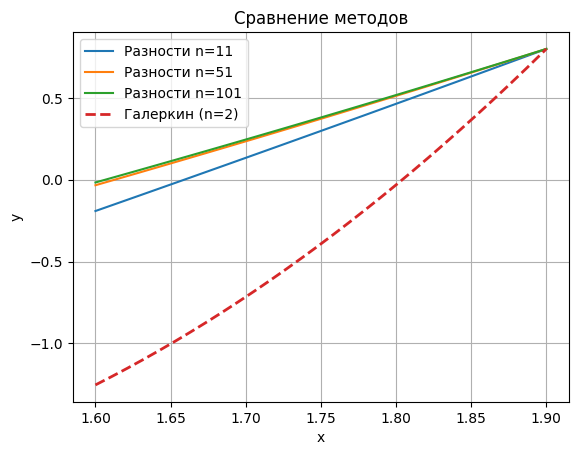

In [47]:
def galerkin():
    x1, x2 = 1.6, 1.9

    # базис: 1, x, x^2
    phi = [
        lambda x: 1,
        lambda x: x,
        lambda x: x**2
    ]

    dphi = [
        lambda x: 0,
        lambda x: 1,
        lambda x: 2*x
    ]

    ddphi = [
        lambda x: 0,
        lambda x: 0,
        lambda x: 2
    ]

    A = np.zeros((3, 3))
    b = np.zeros(3)

    # заполняем систему Галеркина
    for i in range(3):
        for j in range(3):
            integrand = lambda x: (
                ddphi[j](x)
                - 0.5 * x**2 * dphi[j](x)
                + 2 * phi[j](x)
            ) * phi[i](x)

            A[i, j] = quad(integrand, x1, x2)[0]

        rhs = lambda x: x**2 * phi[i](x)
        b[i] = quad(rhs, x1, x2)[0]

    # заменяем 2 уравнения на граничные условия
    # y(1.9) = 0.8
    A[0, :] = [phi[j](1.9) for j in range(3)]
    b[0] = 0.8

    # y(1.6) + 0.7y'(1.6) = 2
    A[1, :] = [phi[j](1.6) + 0.7 * dphi[j](1.6) for j in range(3)]
    b[1] = 2

    # решаем
    a = np.linalg.solve(A, b)

    # функция решения
    x_plot = np.linspace(x1, x2, 200)
    y_plot = a[0] + a[1]*x_plot + a[2]*x_plot**2

    return x_plot, y_plot

plt.figure()

# разностные решения
for n in [11, 51, 101]:
    x, y = finite_difference(n)
    plt.plot(x, y, label=f'Разности n={n}')

# Галеркин
xg, yg = galerkin()
plt.plot(xg, yg, '--', linewidth=2, label='Галеркин (n=2)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Сравнение методов')
plt.legend()
plt.grid()

plt.show()

У Галёркина получается большое отклонение в следствие ограничения n=2.
Чтобы получить точное значение нужно либо использовать модифицированную версию Галёркина, либо увеличить n